# 03_BreathDetect

Breath segmentation notebook (valley -> peak -> valley) for a **single patient**.

This notebook:
- loads one patient file from a user-editable date folder
- removes regions labeled `Apnea=True` by labelers
- optionally detects low-variance apnea segments
- builds breath cycles anchored by peaks
- filters cycles using physiological duration constraints

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, pairwise_distances

# set pandas max columns to 100
pd.set_option('display.max_columns', 100)


In [ ]:
# =========================
# User Arguments (edit here)
# =========================
PARENT_DIR = Path('/home/jhkim/NAVA/03_LABEL_BREATH/stored_results/02_summarized')
ANALYSIS_FOLDER = '20260301'       # easy to change
PATIENT_ID = '04'                  # single-user analysis

# Column names
TIMESTAMP_COL = 'timestamp'
EDI_COL = 'edi'
PEAK_COLS = ['detected_peak', 'gt_peak']
PEAK_MERGE_SEC = 0.25             # if peaks are closer than this, keep higher y

# Apnea label handling from labelers
# strategy: 'any', 'all', or 'specific'
APNEA_LABEL_STRATEGY = 'any'
SPECIFIC_APNEA_LABELERS = ['apnea_label_김재호', 'apnea_label_오창준']  # used only if strategy='specific'

# Preprocessing
BASELINE_MEDIAN_SEC = 20.0
SMOOTHING_SEC = 0.4


SAMPLE_RATE_HZ = 100

# Physiological cycle constraints
MIN_BREATH_SEC = 1.0
MAX_BREATH_SEC = 10.0

# Exclude edges from analysis
EDGE_EXCLUDE_SEC = 10.0


# Peak alignment + clustering
CLUSTER_SOURCE = 'single_peak'      # use 'single_peak' dataframe for alignment/clustering
CLUSTER_K_MIN = 2
CLUSTER_K_MAX = 9
CLUSTER_LINKAGE = 'average'         # recommended with L1/manhattan
CLUSTER_DISTANCE_METRIC = 'mse'  # options: 'mse', 'manhattan', 'mae'

# Output
OUT_DIR = Path('/home/jhkim/NAVA/03_LABEL_BREATH/notebooks/outputs/03_breath_detect') / ANALYSIS_FOLDER
SAVE_RESULTS = True


In [3]:
def to_bool_series(s: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(s):
        return s.fillna(False)
    if pd.api.types.is_numeric_dtype(s):
        return s.fillna(0).astype(float) > 0
    text = s.astype(str).str.strip().str.lower()
    true_set = {'1', 'true', 't', 'yes', 'y'}
    return text.isin(true_set)

def infer_sample_rate_hz(ts: np.ndarray, sample_rate_override=None) -> float:
    if sample_rate_override is not None:
        return float(sample_rate_override)
    dt = np.diff(ts)
    dt = dt[np.isfinite(dt)]
    dt = dt[dt > 0]
    if len(dt) == 0:
        raise ValueError('Cannot infer sample rate: timestamp has no positive increments.')
    med_dt = float(np.median(dt))
    # Heuristic: large step likely milliseconds
    return 1000.0 / med_dt if med_dt > 1.5 else 1.0 / med_dt

def rolling_median_np(arr: np.ndarray, win: int) -> np.ndarray:
    s = pd.Series(arr)
    return s.rolling(window=win, center=True, min_periods=1).median().to_numpy()

def rolling_mean_np(arr: np.ndarray, win: int) -> np.ndarray:
    s = pd.Series(arr)
    return s.rolling(window=win, center=True, min_periods=1).mean().to_numpy()



In [4]:
# Load one patient file
input_file = PARENT_DIR / ANALYSIS_FOLDER / f'movingwinddetected_patient_{PATIENT_ID}.xlsx'
if not input_file.exists():
    raise FileNotFoundError(f'File not found: {input_file}')

df = pd.read_excel(input_file)
required_cols = [TIMESTAMP_COL, EDI_COL] + PEAK_COLS
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f'Missing required columns: {missing}')

ts = pd.to_numeric(df[TIMESTAMP_COL], errors='coerce').to_numpy()
edi_raw = pd.to_numeric(df[EDI_COL], errors='coerce').to_numpy()
peak_masks_raw = {c: to_bool_series(df[c]).to_numpy() for c in PEAK_COLS}

valid = np.isfinite(ts) & np.isfinite(edi_raw)
df = df.loc[valid].reset_index(drop=True)
ts = ts[valid]
edi_raw = edi_raw[valid]
peak_masks_raw = {k: v[valid] for k, v in peak_masks_raw.items()}

fs = infer_sample_rate_hz(ts, SAMPLE_RATE_HZ)
is_ms = np.median(np.diff(ts)) > 1.5
time_sec = (ts - ts[0]) / (1000.0 if is_ms else 1.0)
print(f'Loaded: {input_file.name}')
print(f'Rows: {len(df):,}, fs ~= {fs:.3f} Hz')
print(f'Analysis window: [{EDGE_EXCLUDE_SEC:.1f}s, {max(EDGE_EXCLUDE_SEC, time_sec[-1]-EDGE_EXCLUDE_SEC):.1f}s]')

Loaded: movingwinddetected_patient_04.xlsx
Rows: 300,000, fs ~= 100.000 Hz
Analysis window: [10.0s, 2990.0s]


In [5]:
# Build apnea mask from labelers
apnea_label_cols = [c for c in df.columns if c.startswith('apnea_label_')]
if not apnea_label_cols:
    raise KeyError('No apnea_label_* columns found in file.')

if APNEA_LABEL_STRATEGY == 'specific':
    use_cols = [c for c in SPECIFIC_APNEA_LABELERS if c in apnea_label_cols]
    if not use_cols:
        raise KeyError('No SPECIFIC_APNEA_LABELERS columns found in file.')
else:
    use_cols = apnea_label_cols

apnea_votes = np.column_stack([to_bool_series(df[c]).to_numpy() for c in use_cols])
if APNEA_LABEL_STRATEGY == 'all':
    apnea_label_mask = apnea_votes.all(axis=1)
else:
    # default + 'any' + 'specific'
    apnea_label_mask = apnea_votes.any(axis=1)

# Preprocess EDI (baseline drift removal + smoothing)
baseline_win = max(3, int(round(BASELINE_MEDIAN_SEC * fs)))
smooth_win = max(3, int(round(SMOOTHING_SEC * fs)))
baseline = rolling_median_np(edi_raw, baseline_win)
edi_detrended = edi_raw - baseline
edi_smooth = rolling_mean_np(edi_detrended, smooth_win)

apnea_final_mask = apnea_label_mask
analysis_window_mask = (time_sec >= EDGE_EXCLUDE_SEC) & (time_sec <= (time_sec[-1] - EDGE_EXCLUDE_SEC))
candidate_peak_mask = np.zeros(len(df), dtype=bool)
for c in PEAK_COLS:
    candidate_peak_mask |= peak_masks_raw[c]
candidate_peak_mask &= (~apnea_final_mask) & analysis_window_mask
candidate_idx = np.flatnonzero(candidate_peak_mask)

# Reconcile close gt/detected peaks: keep the one with higher y value
peak_idx = []
if len(candidate_idx):
    cluster = [int(candidate_idx[0])]
    for idx in candidate_idx[1:]:
        idx = int(idx)
        if (time_sec[idx] - time_sec[cluster[-1]]) <= PEAK_MERGE_SEC:
            cluster.append(idx)
        else:
            best = max(cluster, key=lambda j: edi_smooth[j])
            peak_idx.append(best)
            cluster = [idx]
    best = max(cluster, key=lambda j: edi_smooth[j])
    peak_idx.append(best)
peak_idx = np.array(sorted(set(peak_idx)), dtype=int)

print(f'Apnea label cols used: {use_cols}')
print(f'Labeled apnea samples: {apnea_label_mask.sum():,}')
print(f'Final apnea samples:   {apnea_final_mask.sum():,}')
print(f'Analysis window samples: {analysis_window_mask.sum():,}')
print(f'Candidate peaks (OR): {len(candidate_idx):,}')
print(f'Valid peaks after apnea exclusion: {len(peak_idx):,}')

Apnea label cols used: ['apnea_label_김재호', 'apnea_label_오창준']
Labeled apnea samples: 433
Final apnea samples:   433
Analysis window samples: 298,000
Candidate peaks (OR): 3,561
Valid peaks after apnea exclusion: 2,088


In [6]:
# Valley-based breath cutting: breath = segment between two valleys
# Valleys are estimated as minima between consecutive valid peaks.

if len(peak_idx) < 2:
    valleys = np.array([], dtype=int)
else:
    valleys = []
    for i in range(len(peak_idx) - 1):
        left = int(peak_idx[i])
        right = int(peak_idx[i + 1])
        if right <= left:
            continue
        v_rel = np.argmin(edi_smooth[left:right + 1])
        v_idx = left + int(v_rel)
        valleys.append(v_idx)
    valleys = np.array(sorted(set(valleys)), dtype=int)

# Build valley-to-valley breaths and split by peak count
breath_rows = []
breath_id = 0
for i in range(len(valleys) - 1):
    v_start = int(valleys[i])
    v_end = int(valleys[i + 1])
    if v_end <= v_start:
        continue

    # Valley must be below y=1 in detrended signal
    if not (edi_detrended[v_start] < 1 and edi_detrended[v_end] < 1):
        continue

    # Keep full breath inside analysis window
    if not (analysis_window_mask[v_start] and analysis_window_mask[v_end]):
        continue

    dur = (ts[v_end] - ts[v_start]) / 1000.0 if is_ms else (ts[v_end] - ts[v_start])
    if dur < MIN_BREATH_SEC or dur > MAX_BREATH_SEC:
        continue

    # Peaks inside this breath (inclusive boundaries)
    in_seg = peak_idx[(peak_idx >= v_start) & (peak_idx <= v_end)]
    n_peaks = int(len(in_seg))

    sig = edi_smooth[v_start:v_end + 1]
    rel_peaks = (in_seg - v_start).astype(int)

    breath_rows.append({
        'patient_id': PATIENT_ID,
        'breath_id': breath_id,
        'v_start_idx': v_start,
        'v_end_idx': v_end,
        'v_start_t': float(ts[v_start]),
        'v_end_t': float(ts[v_end]),
        'breath_duration_sec': float(dur),
        'n_peaks': n_peaks,
        'peak_indices': in_seg.astype(int).tolist(),
        'peak_rel_indices': rel_peaks.tolist(),
        'signal_len': int(len(sig)),
        'edi_signal': sig.astype(float).tolist(),
    })
    breath_id += 1

breaths_all_df = pd.DataFrame(breath_rows)
breaths_single_peak_df = breaths_all_df[breaths_all_df['n_peaks'] == 1].reset_index(drop=True)
breaths_multi_peak_df = breaths_all_df[breaths_all_df['n_peaks'] > 1].reset_index(drop=True)

# Zero-pad single-peak breaths for clustering
if len(breaths_single_peak_df):
    max_len_single = int(breaths_single_peak_df['signal_len'].max())
    padded_list = []
    pad_mask_list = []
    peak_rel_single = []

    for _, row in breaths_single_peak_df.iterrows():
        sig = np.asarray(row['edi_signal'], dtype=float)
        L = len(sig)
        pad_len = max_len_single - L
        padded = np.pad(sig, (0, pad_len), mode='constant', constant_values=0.0)
        pad_mask = np.zeros(max_len_single, dtype=bool)
        if pad_len > 0:
            pad_mask[L:] = True

        padded_list.append(padded.tolist())
        pad_mask_list.append(pad_mask.tolist())
        peak_rel_single.append(int(row['peak_rel_indices'][0]))

    breaths_single_peak_df['edi_signal_padded'] = padded_list
    breaths_single_peak_df['zero_pad_mask'] = pad_mask_list
    breaths_single_peak_df['peak_rel_idx'] = peak_rel_single
    breaths_single_peak_df['max_len_for_padding'] = max_len_single
else:
    breaths_single_peak_df['edi_signal_padded'] = pd.Series(dtype=object)
    breaths_single_peak_df['zero_pad_mask'] = pd.Series(dtype=object)
    breaths_single_peak_df['peak_rel_idx'] = pd.Series(dtype='Int64')
    breaths_single_peak_df['max_len_for_padding'] = pd.Series(dtype='Int64')

# Optional: pad multi-peak breaths too (useful for later models)
if len(breaths_multi_peak_df):
    max_len_multi = int(breaths_multi_peak_df['signal_len'].max())
    mp_padded, mp_mask = [], []
    for _, row in breaths_multi_peak_df.iterrows():
        sig = np.asarray(row['edi_signal'], dtype=float)
        L = len(sig)
        pad_len = max_len_multi - L
        padded = np.pad(sig, (0, pad_len), mode='constant', constant_values=0.0)
        pad_mask = np.zeros(max_len_multi, dtype=bool)
        if pad_len > 0:
            pad_mask[L:] = True
        mp_padded.append(padded.tolist())
        mp_mask.append(pad_mask.tolist())
    breaths_multi_peak_df['edi_signal_padded'] = mp_padded
    breaths_multi_peak_df['zero_pad_mask'] = mp_mask
    breaths_multi_peak_df['max_len_for_padding'] = max_len_multi

print(f'Valleys detected: {len(valleys):,}')
print(f'All breaths (valley-to-valley): {len(breaths_all_df):,}')
print(f'Single-peak breaths: {len(breaths_single_peak_df):,}')
print(f'Multi-peak breaths: {len(breaths_multi_peak_df):,}')

breaths_single_peak_df.head()



Valleys detected: 2,087
All breaths (valley-to-valley): 1,450
Single-peak breaths: 1,447
Multi-peak breaths: 3


,patient_id,breath_id,v_start_idx,v_end_idx,v_start_t,v_end_t,breath_duration_sec,n_peaks,peak_indices,peak_rel_indices,signal_len,edi_signal,edi_signal_padded,zero_pad_mask,peak_rel_idx,max_len_for_padding
0,04,0,1209,1348,479440.0,480830.0,1.39,1,[1263],[54],140,"[-0.7849999999999998, -0.7727499999999997, -0....","[-0.7849999999999998, -0.7727499999999997, -0....","[False, False, False, False, False, False, Fal...",54,748
1,04,1,1348,1531,480830.0,482660.0,1.83,1,[1441],[93],184,"[-0.7673749999999999, -0.75975, -0.75025000000...","[-0.7673749999999999, -0.75975, -0.75025000000...","[False, False, False, False, False, False, Fal...",93,748
2,04,2,1531,1819,482660.0,485540.0,2.88,1,[1679],[148],289,"[-0.4495, -0.4467499999999999, -0.443999999999...","[-0.4495, -0.4467499999999999, -0.443999999999...","[False, False, False, False, False, False, Fal...",148,748
3,04,3,1819,1949,485540.0,486840.0,1.30,1,[1876],[57],131,"[-0.006374999999999864, -0.0031249999999998666...","[-0.006374999999999864, -0.0031249999999998666...","[False, False, False, False, False, False, Fal...",57,748
4,04,4,1949,2183,486840.0,489180.0,2.34,1,[2132],[183],235,"[-0.8794999999999998, -0.8789999999999998, -0....","[-0.8794999999999998, -0.8789999999999998, -0....","[False, False, False, False, False, False, Fal...",183,748


In [7]:
breaths_multi_peak_df

,patient_id,breath_id,v_start_idx,v_end_idx,v_start_t,v_end_t,breath_duration_sec,n_peaks,peak_indices,peak_rel_indices,signal_len,edi_signal,edi_signal_padded,zero_pad_mask,max_len_for_padding
0,04,563,110222,110348,1569570.0,1570830.0,1.26,2,"[110298, 110348]","[76, 126]",127,"[-0.9030000000000001, -0.9025000000000001, -0....","[-0.9030000000000001, -0.9025000000000001, -0....","[False, False, False, False, False, False, Fal...",129
1,04,943,186265,186393,2330000.0,2331280.0,1.28,2,"[186265, 186345]","[0, 80]",129,"[-0.9335000000000001, -0.8843750000000001, -0....","[-0.9335000000000001, -0.8843750000000001, -0....","[False, False, False, False, False, False, Fal...",129
2,04,1064,210573,210692,2573080.0,2574270.0,1.19,2,"[210662, 210692]","[89, 119]",120,"[-1.7730000000000008, -1.7696250000000002, -1....","[-1.7730000000000008, -1.7696250000000002, -1....","[False, False, False, False, False, False, Fal...",129


In [8]:
breaths_all_df

,patient_id,breath_id,v_start_idx,v_end_idx,v_start_t,v_end_t,breath_duration_sec,n_peaks,peak_indices,peak_rel_indices,signal_len,edi_signal
0,04,0,1209,1348,479440.0,480830.0,1.39,1,[1263],[54],140,"[-0.7849999999999998, -0.7727499999999997, -0...."
1,04,1,1348,1531,480830.0,482660.0,1.83,1,[1441],[93],184,"[-0.7673749999999999, -0.75975, -0.75025000000..."
2,04,2,1531,1819,482660.0,485540.0,2.88,1,[1679],[148],289,"[-0.4495, -0.4467499999999999, -0.443999999999..."
3,04,3,1819,1949,485540.0,486840.0,1.30,1,[1876],[57],131,"[-0.006374999999999864, -0.0031249999999998666..."
4,04,4,1949,2183,486840.0,489180.0,2.34,1,[2132],[183],235,"[-0.8794999999999998, -0.8789999999999998, -0...."
...,...,...,...,...,...,...,...,...,...,...,...,...
1445,04,1445,297964,298114,3446990.0,3448490.0,1.50,1,[298030],[66],151,"[-0.9790000000000006, -0.9773750000000007, -0...."
1446,04,1446,298114,298366,3448490.0,3451010.0,2.52,1,[298180],[66],253,"[-0.7315000000000007, -0.7156250000000008, -0...."
1447,04,1447,298366,298550,3451010.0,3452850.0,1.84,1,[298438],[72],185,"[-2.382625000000001, -2.367375000000001, -2.35..."
1448,04,1448,298550,298692,3452850.0,3454270.0,1.42,1,[298628],[78],143,"[-3.097250000000001, -3.095375000000001, -3.07..."


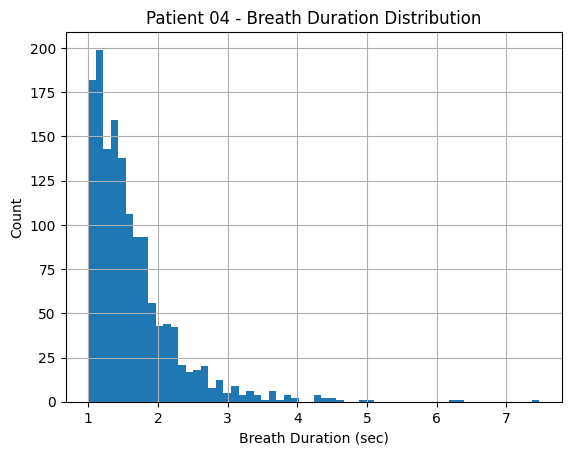

In [18]:
plt.hist(breaths_all_df['breath_duration_sec'], bins=60)
plt.xlabel('Breath Duration (sec)')
plt.ylabel('Count')
plt.title(f'Patient {PATIENT_ID} - Breath Duration Distribution')
plt.grid(True)
plt.show()

In [9]:
# Save results
# if SAVE_RESULTS:
    # OUT_DIR.mkdir(parents=True, exist_ok=True)

    # single_csv = OUT_DIR / f'breaths_single_peak_patient_{PATIENT_ID}.csv'
    # multi_csv = OUT_DIR / f'breaths_multi_peak_patient_{PATIENT_ID}.csv'
    # all_csv = OUT_DIR / f'breaths_all_patient_{PATIENT_ID}.csv'

    # # CSV keeps list-like columns as strings; also save pickle for exact python objects
    # single_pkl = OUT_DIR / f'breaths_single_peak_patient_{PATIENT_ID}.pkl'
    # multi_pkl = OUT_DIR / f'breaths_multi_peak_patient_{PATIENT_ID}.pkl'

    # breaths_all_df.to_csv(all_csv, index=False)
    # breaths_single_peak_df.to_csv(single_csv, index=False)
    # breaths_multi_peak_df.to_csv(multi_csv, index=False)

    # breaths_single_peak_df.to_pickle(single_pkl)
    # breaths_multi_peak_df.to_pickle(multi_pkl)

    # print(f'Saved: {all_csv}')
    # print(f'Saved: {single_csv}')
    # print(f'Saved: {multi_csv}')
    # print(f'Saved: {single_pkl}')
    # print(f'Saved: {multi_pkl}')



In [10]:
# Peak alignment helper (same x position) + two-sided zero padding

def _build_anchor_peak_rel_idx(df_in: pd.DataFrame, mode: str) -> pd.DataFrame:
    df = df_in.copy()
    if len(df) == 0:
        return df

    if mode == 'single_peak':
        if 'peak_rel_idx' not in df.columns:
            raise KeyError("single_peak mode requires 'peak_rel_idx'.")
        df['anchor_peak_rel_idx'] = df['peak_rel_idx'].astype(int)
        return df

    if mode == 'all_breaths':
        anchors = []
        for _, row in df.iterrows():
            sig = np.asarray(row['edi_signal'], dtype=float)
            rel = row['peak_rel_indices']
            if not isinstance(rel, (list, tuple, np.ndarray)) or len(rel) == 0:
                anchors.append(np.nan)
                continue
            rel_arr = np.asarray(rel, dtype=int)
            rel_arr = rel_arr[(rel_arr >= 0) & (rel_arr < len(sig))]
            if len(rel_arr) == 0:
                anchors.append(np.nan)
                continue
            # Use highest-y peak inside this breath as anchor for alignment
            best_rel = int(rel_arr[np.argmax(sig[rel_arr])])
            anchors.append(best_rel)
        df['anchor_peak_rel_idx'] = anchors
        df = df[df['anchor_peak_rel_idx'].notna()].copy()
        df['anchor_peak_rel_idx'] = df['anchor_peak_rel_idx'].astype(int)
        return df

    raise ValueError(f'Unknown mode: {mode}')


def align_by_anchor_peak(df_in: pd.DataFrame, mode: str) -> pd.DataFrame:
    df = _build_anchor_peak_rel_idx(df_in, mode=mode)
    if len(df) == 0:
        return df

    peak_rel = df['anchor_peak_rel_idx'].astype(int).to_numpy()
    sig_len = df['signal_len'].astype(int).to_numpy()
    left_ctx = peak_rel
    right_ctx = sig_len - 1 - peak_rel

    aligned_peak_idx = int(left_ctx.max())
    max_right_ctx = int(right_ctx.max())
    target_len = aligned_peak_idx + 1 + max_right_ctx

    aligned_signals = []
    zero_pad_mask = []
    left_pad_len = []
    right_pad_len = []

    for _, row in df.iterrows():
        sig = np.asarray(row['edi_signal'], dtype=float)
        p = int(row['anchor_peak_rel_idx'])
        L = int(len(sig))

        lp = aligned_peak_idx - p
        rp = target_len - (lp + L)
        if lp < 0 or rp < 0:
            raise RuntimeError('Padding logic failed: negative pad length encountered.')

        sig_aligned = np.pad(sig, (lp, rp), mode='constant', constant_values=0.0)
        mask = np.zeros(target_len, dtype=bool)
        if lp > 0:
            mask[:lp] = True
        if rp > 0:
            mask[lp + L:] = True

        aligned_signals.append(sig_aligned.tolist())
        zero_pad_mask.append(mask.tolist())
        left_pad_len.append(int(lp))
        right_pad_len.append(int(rp))

    df['aligned_peak_idx'] = aligned_peak_idx
    df['signal_aligned'] = aligned_signals
    df['zero_pad_mask_aligned'] = zero_pad_mask
    df['left_pad_len'] = left_pad_len
    df['right_pad_len'] = right_pad_len
    df['target_len'] = target_len
    return df



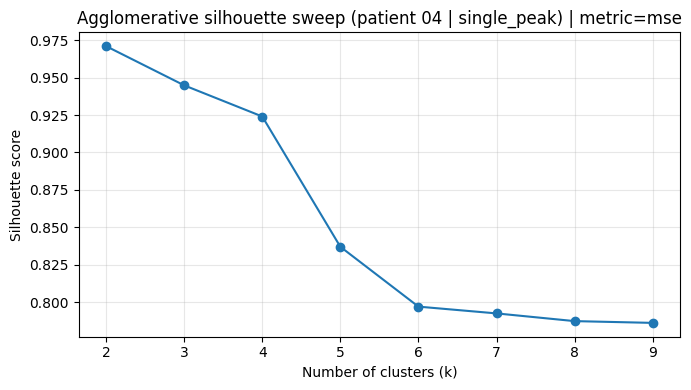

[patient 04 | single_peak] samples=1447, best_k=2, metric=mse


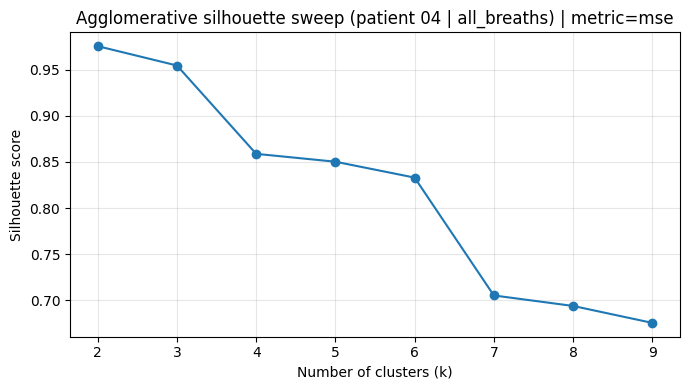

[patient 04 | all_breaths] samples=1450, best_k=2, metric=mse
single_peak silhouette:


,k,silhouette
0,2,0.971063
1,3,0.944877
2,4,0.924047
3,5,0.836966
4,6,0.796960
5,7,0.792430
6,8,0.787276
7,9,0.786093


all_breaths silhouette:


,k,silhouette
0,2,0.975634
1,3,0.954645
2,4,0.858777
3,5,0.850252
4,6,0.833003
5,7,0.705122
6,8,0.693733
7,9,0.675356


In [11]:
# Agglomerative clustering + silhouette sweep k=2..9 (metric configurable)

def build_distance_matrix(X: np.ndarray, metric_name: str) -> np.ndarray:
    m = metric_name.lower().strip()
    if m == 'manhattan':
        return pairwise_distances(X, metric='manhattan')
    if m == 'mae':
        # MAE = mean absolute error across aligned time points
        return pairwise_distances(X, metric='manhattan') / X.shape[1]
    if m == 'mse':
        # MSE = mean squared error across aligned time points
        return pairwise_distances(X, metric='sqeuclidean') / X.shape[1]
    raise ValueError("CLUSTER_DISTANCE_METRIC must be one of: 'mse', 'manhattan', 'mae'.")


def run_agglomerative_with_silhouette(df_aligned: pd.DataFrame, title_suffix: str):
    if len(df_aligned) == 0:
        raise ValueError(f'No breaths available for clustering: {title_suffix}')

    X = np.vstack(df_aligned['signal_aligned'].apply(lambda v: np.asarray(v, dtype=float)).to_numpy())
    D = build_distance_matrix(X, CLUSTER_DISTANCE_METRIC)
    n_samples = X.shape[0]

    k_min = max(2, int(CLUSTER_K_MIN))
    k_max = min(int(CLUSTER_K_MAX), n_samples - 1)
    if k_max < k_min:
        raise ValueError(f'Not enough samples ({n_samples}) for clustering range {k_min}..{CLUSTER_K_MAX}.')

    rows = []
    for k in range(k_min, k_max + 1):
        try:
            model = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage=CLUSTER_LINKAGE)
        except TypeError:
            model = AgglomerativeClustering(n_clusters=k, affinity='precomputed', linkage=CLUSTER_LINKAGE)

        labels = model.fit_predict(D)
        if len(np.unique(labels)) < 2:
            continue
        sil = silhouette_score(D, labels, metric='precomputed')
        rows.append({'k': int(k), 'silhouette': float(sil)})

    sil_df = pd.DataFrame(rows)
    if sil_df.empty:
        raise RuntimeError(f'Silhouette computation failed for all k values: {title_suffix}')

    best_k = int(sil_df.loc[sil_df['silhouette'].idxmax(), 'k'])
    try:
        best_model = AgglomerativeClustering(n_clusters=best_k, metric='precomputed', linkage=CLUSTER_LINKAGE)
    except TypeError:
        best_model = AgglomerativeClustering(n_clusters=best_k, affinity='precomputed', linkage=CLUSTER_LINKAGE)

    out_df = df_aligned.copy()
    out_df['cluster_label'] = best_model.fit_predict(D)

    plt.figure(figsize=(7, 4))
    plt.plot(sil_df['k'], sil_df['silhouette'], marker='o')
    plt.xticks(range(k_min, k_max + 1))
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette score')
    plt.title(f'Agglomerative silhouette sweep ({title_suffix}) | metric={CLUSTER_DISTANCE_METRIC}')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'[{title_suffix}] samples={n_samples}, best_k={best_k}, metric={CLUSTER_DISTANCE_METRIC}')
    return out_df, sil_df


# 1) Single-peak breaths
cluster_single_df = align_by_anchor_peak(breaths_single_peak_df, mode='single_peak')
cluster_single_df, silhouette_single_df = run_agglomerative_with_silhouette(
    cluster_single_df,
    title_suffix=f'patient {PATIENT_ID} | single_peak'
)

# 2) All breaths (anchor peak = highest-y peak within breath)
cluster_all_df = align_by_anchor_peak(breaths_all_df, mode='all_breaths')
cluster_all_df, silhouette_all_df = run_agglomerative_with_silhouette(
    cluster_all_df,
    title_suffix=f'patient {PATIENT_ID} | all_breaths'
)

print('single_peak silhouette:')
display(silhouette_single_df)
print('all_breaths silhouette:')
display(silhouette_all_df)



In [12]:
# Manual clustering run on aligned all-breath data (fixed k)
cluster_df = cluster_all_df.copy()
if len(cluster_df) == 0:
    raise ValueError('cluster_all_df is empty. Run the alignment/clustering cells above first.')

X = np.vstack(cluster_df['signal_aligned'].apply(lambda v: np.asarray(v, dtype=float)).to_numpy())
D = build_distance_matrix(X, CLUSTER_DISTANCE_METRIC)

best_k = 7
print(f'Best k by silhouette (L1): {best_k}')

# Fit best model and store labels
try:
    best_model = AgglomerativeClustering(n_clusters=best_k, metric='precomputed', linkage=CLUSTER_LINKAGE)
except TypeError:
    best_model = AgglomerativeClustering(n_clusters=best_k, affinity='precomputed', linkage=CLUSTER_LINKAGE)

cluster_df['cluster_label'] = best_model.fit_predict(D)

# Count the number of breaths in each cluster
cluster_counts = cluster_df['cluster_label'].value_counts().sort_index()
print('Cluster counts:')
print(cluster_counts)


Best k by silhouette (L1): 7
Cluster counts:
cluster_label
0      24
1       2
2       2
3    1419
4       1
5       1
6       1
Name: count, dtype: int64


In [13]:
cluster_df

,patient_id,breath_id,v_start_idx,v_end_idx,v_start_t,v_end_t,breath_duration_sec,n_peaks,peak_indices,peak_rel_indices,signal_len,edi_signal,anchor_peak_rel_idx,aligned_peak_idx,signal_aligned,zero_pad_mask_aligned,left_pad_len,right_pad_len,target_len,cluster_label
0,04,0,1209,1348,479440.0,480830.0,1.39,1,[1263],[54],140,"[-0.7849999999999998, -0.7727499999999997, -0....",54,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",423,531,1094,3
1,04,1,1348,1531,480830.0,482660.0,1.83,1,[1441],[93],184,"[-0.7673749999999999, -0.75975, -0.75025000000...",93,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",384,526,1094,3
2,04,2,1531,1819,482660.0,485540.0,2.88,1,[1679],[148],289,"[-0.4495, -0.4467499999999999, -0.443999999999...",148,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",329,476,1094,3
3,04,3,1819,1949,485540.0,486840.0,1.30,1,[1876],[57],131,"[-0.006374999999999864, -0.0031249999999998666...",57,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",420,543,1094,3
4,04,4,1949,2183,486840.0,489180.0,2.34,1,[2132],[183],235,"[-0.8794999999999998, -0.8789999999999998, -0....",183,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",294,565,1094,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,04,1445,297964,298114,3446990.0,3448490.0,1.50,1,[298030],[66],151,"[-0.9790000000000006, -0.9773750000000007, -0....",66,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",411,532,1094,3
1446,04,1446,298114,298366,3448490.0,3451010.0,2.52,1,[298180],[66],253,"[-0.7315000000000007, -0.7156250000000008, -0....",66,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",411,430,1094,3
1447,04,1447,298366,298550,3451010.0,3452850.0,1.84,1,[298438],[72],185,"[-2.382625000000001, -2.367375000000001, -2.35...",72,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",405,504,1094,3
1448,04,1448,298550,298692,3452850.0,3454270.0,1.42,1,[298628],[78],143,"[-3.097250000000001, -3.095375000000001, -3.07...",78,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",399,552,1094,3


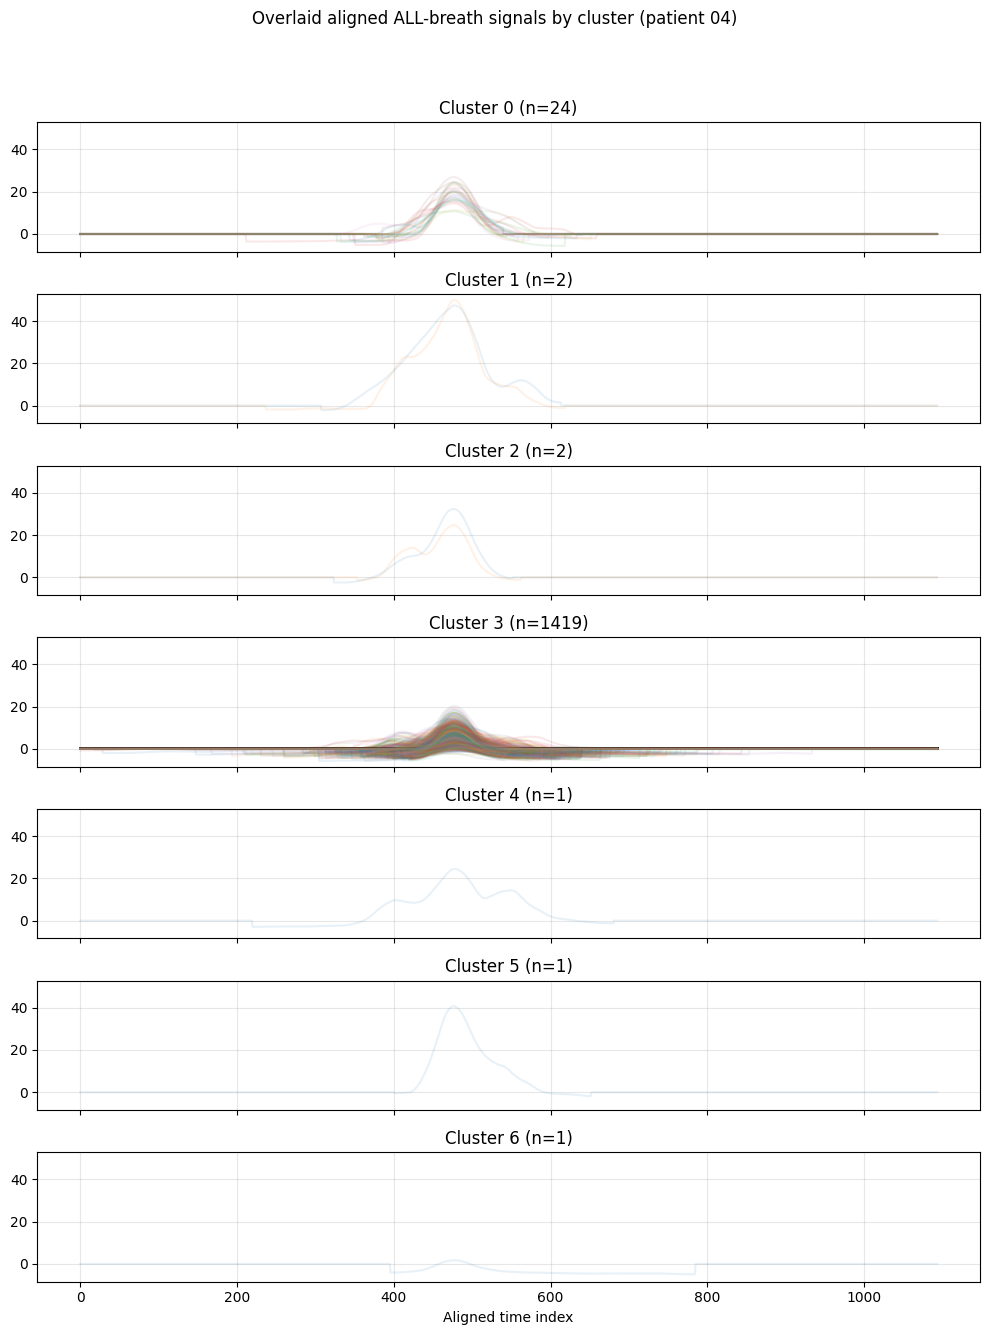

In [14]:
# Plot overlaid signals for each cluster
fig, axes = plt.subplots(nrows=best_k, ncols=1, figsize=(10, 2 * best_k), sharex=True, sharey=True)
for k in range(best_k):
    ax = axes[k]
    cluster_signals = X[cluster_df['cluster_label'] == k]
    for sig in cluster_signals:
        ax.plot(sig, alpha=0.1)
    ax.set_title(f'Cluster {k} (n={len(cluster_signals)})')
    ax.grid(alpha=0.3)
plt.xlabel('Aligned time index')
plt.suptitle(f'Overlaid aligned ALL-breath signals by cluster (patient {PATIENT_ID})')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [26]:
stats_df

,patient_id,breath_id,v_start_idx,v_end_idx,v_start_t,v_end_t,breath_duration_sec,n_peaks,peak_indices,peak_rel_indices,signal_len,edi_signal,anchor_peak_rel_idx,aligned_peak_idx,signal_aligned,zero_pad_mask_aligned,left_pad_len,right_pad_len,target_len,cluster_label,signal_len,max_edi,min_edi,mean_edi,std_edi,ptp_edi,auc,auc_abs,auc_pos,peak_edi,rise_time_sec,fall_time_sec,rise_slope,fall_slope
0,04,0,1209,1348,479440.0,480830.0,1.39,1,[1263],[54],140,"[-0.7849999999999998, -0.7727499999999997, -0....",54,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",423,531,1094,3,140.0,4.394625,-0.785000,1.450482,1.780467,5.179625,2.038437,2.430248,2.234343,4.394625,0.54,0.85,9.591898,6.072941
1,04,1,1348,1531,480830.0,482660.0,1.83,1,[1441],[93],184,"[-0.7673749999999999, -0.75975, -0.75025000000...",93,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",384,526,1094,3,184.0,6.379875,-0.767375,2.199264,2.364496,7.147250,4.052731,4.434749,4.243740,6.379875,0.93,0.90,7.685215,7.588194
2,04,2,1531,1819,482660.0,485540.0,2.88,1,[1679],[148],289,"[-0.4495, -0.4467499999999999, -0.443999999999...",148,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",329,476,1094,3,289.0,5.098375,-0.449500,1.528484,1.796964,5.547875,4.419599,4.963096,4.691348,5.098375,1.48,1.40,3.748564,3.646250
3,04,3,1819,1949,485540.0,486840.0,1.30,1,[1876],[57],131,"[-0.006374999999999864, -0.0031249999999998666...",57,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",420,543,1094,3,131.0,2.241500,-0.879500,0.693762,1.025503,3.121000,0.913258,1.313812,1.113535,2.117250,0.57,0.73,3.725658,4.105137
4,04,4,1949,2183,486840.0,489180.0,2.34,1,[2132],[183],235,"[-0.8794999999999998, -0.8789999999999998, -0....",183,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",294,565,1094,3,235.0,0.397875,-0.879500,-0.564894,0.405179,1.277375,-1.320536,1.510173,0.094819,0.342625,1.83,0.51,0.667828,1.678922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,04,1445,297964,298114,3446990.0,3448490.0,1.50,1,[298030],[66],151,"[-0.9790000000000006, -0.9773750000000007, -0....",66,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",411,532,1094,3,151.0,6.054125,-0.979000,2.175363,2.307586,7.033125,3.293350,3.692955,3.493152,6.054125,0.66,0.84,10.656250,8.078125
1446,04,1446,298114,298366,3448490.0,3451010.0,2.52,1,[298180],[66],253,"[-0.7315000000000007, -0.7156250000000008, -0....",66,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",411,430,1094,3,253.0,9.790125,-2.382625,1.022078,3.962514,12.172750,2.601427,7.779603,5.190515,9.790125,0.66,1.86,15.941856,6.544489
1447,04,1447,298366,298550,3451010.0,3452850.0,1.84,1,[298438],[72],185,"[-2.382625000000001, -2.367375000000001, -2.35...",72,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",405,504,1094,3,185.0,7.948000,-3.097250,0.883465,3.616416,11.045250,1.661809,5.542413,3.602111,7.948000,0.72,1.12,14.348090,9.861830
1448,04,1448,298550,298692,3452850.0,3454270.0,1.42,1,[298628],[78],143,"[-3.097250000000001, -3.095375000000001, -3.07...",78,477,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[True, True, True, True, True, True, True, Tru...",399,552,1094,3,143.0,11.498250,-3.097250,2.655409,5.038291,14.595500,3.822570,6.222260,5.022415,11.498250,0.78,0.64,18.712179,21.043750


/tmp/ipykernel_3436995/429204962.py:42: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = float(np.trapz(sig, dx=1.0 / fs))
/tmp/ipykernel_3436995/429204962.py:43: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_abs = float(np.trapz(np.abs(sig), dx=1.0 / fs))
/tmp/ipykernel_3436995/429204962.py:44: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_pos = float(np.trapz(np.clip(sig, 0, None), dx=1.0 / fs))


Per-cluster summary statistics:


breath_duration_sec  signal_len                max_edi  \
                             mean        mean        mean       mean   
cluster_label                                                          
0                        2.102083  211.208333  211.208333  19.087974   
1                        3.430000  344.000000  344.000000  48.723250   
2                        2.175000  218.500000  218.500000  28.514125   
3                        1.613263  162.326286  162.326286   5.159250   
4                        4.600000  461.000000  461.000000  24.398000   
5                        2.500000  251.000000  251.000000  40.692500   
6                        3.880000  389.000000  389.000000   1.773125   

                min_edi   mean_edi    std_edi    ptp_edi        auc  \
                   mean       mean       mean       mean       mean   
cluster_label                                                         
0             -2.477365   6.127539   7.205723  21.565339  11.913530   
1             -1.993625  14.151075  15.343890  50.716875  47.589614   
2             -1.984938   9.028780   9.675622  30.499063  19.785141   
3             -2.473154   0.793818   2.504318   7.632404   1.211002   
4             -2.952000   5.185176   7.960472  27.350000  23.924851   
5             -1.901250  11.228731  13.416622  42.593750  28.195609   
6             -4.924500  -3.379932   1.824351   6.697625 -13.102805   

                 auc_abs    auc_pos   peak_edi rise_time_sec fall_time_sec  \
                    mean       mean       mean          mean          mean   
cluster_label                                                                
0              14.677149  13.295339  19.087974      1.097917      1.004167   
1              50.289001  48.939308  48.723250      2.045000      1.385000   
2              21.153047  20.469094  28.514125      1.380000      0.795000   
3               3.894493   2.552747   5.127951      0.691071      0.922192   
4              31.766476  27.845664  24.398000      2.570000      2.030000   
5              29.477898  28.836754  40.692500      0.760000      1.740000   
6              13.990080   0.443637   1.773125      0.810000      3.070000   

              rise_slope fall_slope  
                    mean       mean  
cluster_label                        
0              21.139687  23.223284  
1              25.471099  34.991507  
2              22.023040  37.430834  
3              11.056760   8.402544  
4              10.642023  12.652217  
5              54.065954  24.479167  
6               7.252623   2.181637

/tmp/ipykernel_3436995/429204962.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
/tmp/ipykernel_3436995/429204962.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
/tmp/ipykernel_3436995/429204962.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
/tmp/ipykernel_3436995/429204962.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.box

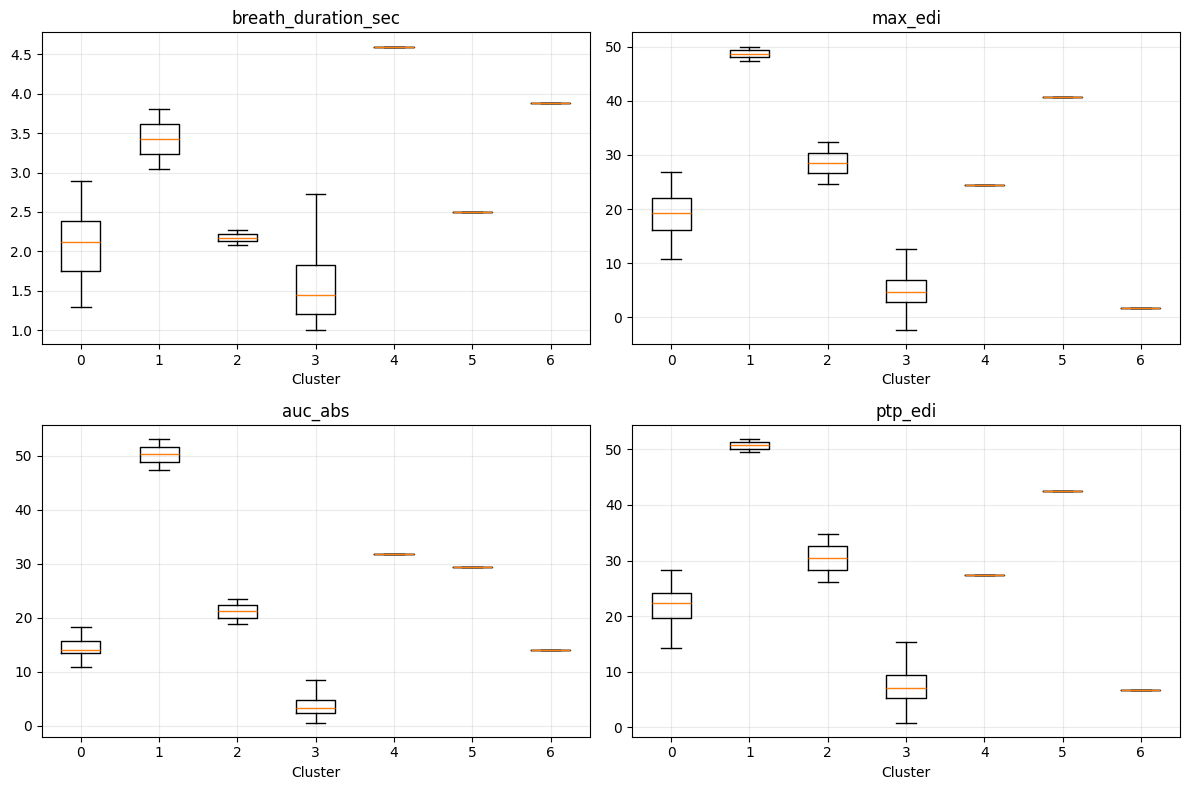

,patient_id,breath_id,cluster_label,breath_duration_sec,signal_len,signal_len,max_edi,min_edi,mean_edi,std_edi,ptp_edi,auc,auc_abs,auc_pos,peak_edi,rise_time_sec,fall_time_sec,rise_slope,fall_slope
0,04,0,3,1.39,140,140.0,4.394625,-0.785000,1.450482,1.780467,5.179625,2.038437,2.430248,2.234343,4.394625,0.54,0.85,9.591898,6.072941
1,04,1,3,1.83,184,184.0,6.379875,-0.767375,2.199264,2.364496,7.147250,4.052731,4.434749,4.243740,6.379875,0.93,0.90,7.685215,7.588194
2,04,2,3,2.88,289,289.0,5.098375,-0.449500,1.528484,1.796964,5.547875,4.419599,4.963096,4.691348,5.098375,1.48,1.40,3.748564,3.646250
3,04,3,3,1.30,131,131.0,2.241500,-0.879500,0.693762,1.025503,3.121000,0.913258,1.313812,1.113535,2.117250,0.57,0.73,3.725658,4.105137
4,04,4,3,2.34,235,235.0,0.397875,-0.879500,-0.564894,0.405179,1.277375,-1.320536,1.510173,0.094819,0.342625,1.83,0.51,0.667828,1.678922


In [29]:
# Analyze the statistic for each cluster (e.g., breath duration, max EDI, area under curve, etc.)
if 'cluster_df' not in globals():
    raise ValueError('cluster_df is not defined. Run clustering cells first.')
if len(cluster_df) == 0:
    raise ValueError('cluster_df is empty.')
if 'cluster_label' not in cluster_df.columns:
    raise ValueError('cluster_label not found in cluster_df. Run clustering fit first.')

stats_df = cluster_df.copy()

def _compute_features(row):
    sig = np.asarray(row['edi_signal'], dtype=float)
    L = len(sig)
    if L == 0:
        return pd.Series({
            'signal_len': 0,
            'max_edi': np.nan,
            'min_edi': np.nan,
            'mean_edi': np.nan,
            'std_edi': np.nan,
            'ptp_edi': np.nan,
            'auc': np.nan,
            'auc_abs': np.nan,
            'auc_pos': np.nan,
            'peak_edi': np.nan,
            'rise_time_sec': np.nan,
            'fall_time_sec': np.nan,
            'rise_slope': np.nan,
            'fall_slope': np.nan,
        })

    peak_rel = int(row['anchor_peak_rel_idx']) if 'anchor_peak_rel_idx' in row and pd.notna(row['anchor_peak_rel_idx']) else int(np.argmax(sig))
    peak_rel = max(0, min(peak_rel, L - 1))

    max_edi = float(np.max(sig))
    min_edi = float(np.min(sig))
    mean_edi = float(np.mean(sig))
    std_edi = float(np.std(sig))
    ptp_edi = max_edi - min_edi

    # Areas in EDI*sec using dt=1/fs
    auc = float(np.trapz(sig, dx=1.0 / fs))
    auc_abs = float(np.trapz(np.abs(sig), dx=1.0 / fs))
    auc_pos = float(np.trapz(np.clip(sig, 0, None), dx=1.0 / fs))

    peak_edi = float(sig[peak_rel])
    rise_time_sec = float(peak_rel / fs)
    fall_time_sec = float((L - 1 - peak_rel) / fs)

    start_val = float(sig[0])
    end_val = float(sig[-1])
    rise_slope = (peak_edi - start_val) / max(rise_time_sec, 1.0 / fs)
    fall_slope = (peak_edi - end_val) / max(fall_time_sec, 1.0 / fs)

    return pd.Series({
        'signal_len': int(L),
        'max_edi': max_edi,
        'min_edi': min_edi,
        'mean_edi': mean_edi,
        'std_edi': std_edi,
        'ptp_edi': ptp_edi,
        'auc': auc,
        'auc_abs': auc_abs,
        'auc_pos': auc_pos,
        'peak_edi': peak_edi,
        'rise_time_sec': rise_time_sec,
        'fall_time_sec': fall_time_sec,
        'rise_slope': float(rise_slope),
        'fall_slope': float(fall_slope),
    })

feat_df = stats_df.apply(_compute_features, axis=1)
stats_df = pd.concat([stats_df, feat_df], axis=1)

# Keep a compact per-breath table for downstream analysis
cluster_breath_stats_df = stats_df[[
    'patient_id', 'breath_id', 'cluster_label', 'breath_duration_sec',
    'signal_len', 'max_edi', 'min_edi', 'mean_edi', 'std_edi', 'ptp_edi',
    'auc', 'auc_abs', 'auc_pos', 'peak_edi', 'rise_time_sec', 'fall_time_sec',
    'rise_slope', 'fall_slope'
]].copy()

summary_cols = [
    'breath_duration_sec', 'signal_len', 'max_edi', 'min_edi', 'mean_edi', 'std_edi', 'ptp_edi',
    'auc', 'auc_abs', 'auc_pos', 'peak_edi', 'rise_time_sec', 'fall_time_sec', 'rise_slope', 'fall_slope'
]

cluster_summary_df = cluster_breath_stats_df.groupby('cluster_label')[summary_cols].agg(['mean'])
print('Per-cluster summary statistics:')
display(cluster_summary_df)

# Simple visualization for key metrics
plot_metrics = ['breath_duration_sec', 'max_edi', 'auc_abs', 'ptp_edi']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, m in zip(axes.ravel(), plot_metrics):
    data = [cluster_breath_stats_df.loc[cluster_breath_stats_df['cluster_label'] == k, m].dropna().to_numpy()
            for k in sorted(cluster_breath_stats_df['cluster_label'].unique())]
    labels = [str(k) for k in sorted(cluster_breath_stats_df['cluster_label'].unique())]
    ax.boxplot(data, labels=labels, showfliers=False)
    ax.set_title(m)
    ax.set_xlabel('Cluster')
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

cluster_breath_stats_df.head()



In [30]:
cluster_summary_df

breath_duration_sec  signal_len                max_edi  \
                             mean        mean        mean       mean   
cluster_label                                                          
0                        2.102083  211.208333  211.208333  19.087974   
1                        3.430000  344.000000  344.000000  48.723250   
2                        2.175000  218.500000  218.500000  28.514125   
3                        1.613263  162.326286  162.326286   5.159250   
4                        4.600000  461.000000  461.000000  24.398000   
5                        2.500000  251.000000  251.000000  40.692500   
6                        3.880000  389.000000  389.000000   1.773125   

                min_edi   mean_edi    std_edi    ptp_edi        auc  \
                   mean       mean       mean       mean       mean   
cluster_label                                                         
0             -2.477365   6.127539   7.205723  21.565339  11.913530   
1             -1.993625  14.151075  15.343890  50.716875  47.589614   
2             -1.984938   9.028780   9.675622  30.499063  19.785141   
3             -2.473154   0.793818   2.504318   7.632404   1.211002   
4             -2.952000   5.185176   7.960472  27.350000  23.924851   
5             -1.901250  11.228731  13.416622  42.593750  28.195609   
6             -4.924500  -3.379932   1.824351   6.697625 -13.102805   

                 auc_abs    auc_pos   peak_edi rise_time_sec fall_time_sec  \
                    mean       mean       mean          mean          mean   
cluster_label                                                                
0              14.677149  13.295339  19.087974      1.097917      1.004167   
1              50.289001  48.939308  48.723250      2.045000      1.385000   
2              21.153047  20.469094  28.514125      1.380000      0.795000   
3               3.894493   2.552747   5.127951      0.691071      0.922192   
4              31.766476  27.845664  24.398000      2.570000      2.030000   
5              29.477898  28.836754  40.692500      0.760000      1.740000   
6              13.990080   0.443637   1.773125      0.810000      3.070000   

              rise_slope fall_slope  
                    mean       mean  
cluster_label                        
0              21.139687  23.223284  
1              25.471099  34.991507  
2              22.023040  37.430834  
3              11.056760   8.402544  
4              10.642023  12.652217  
5              54.065954  24.479167  
6               7.252623   2.181637

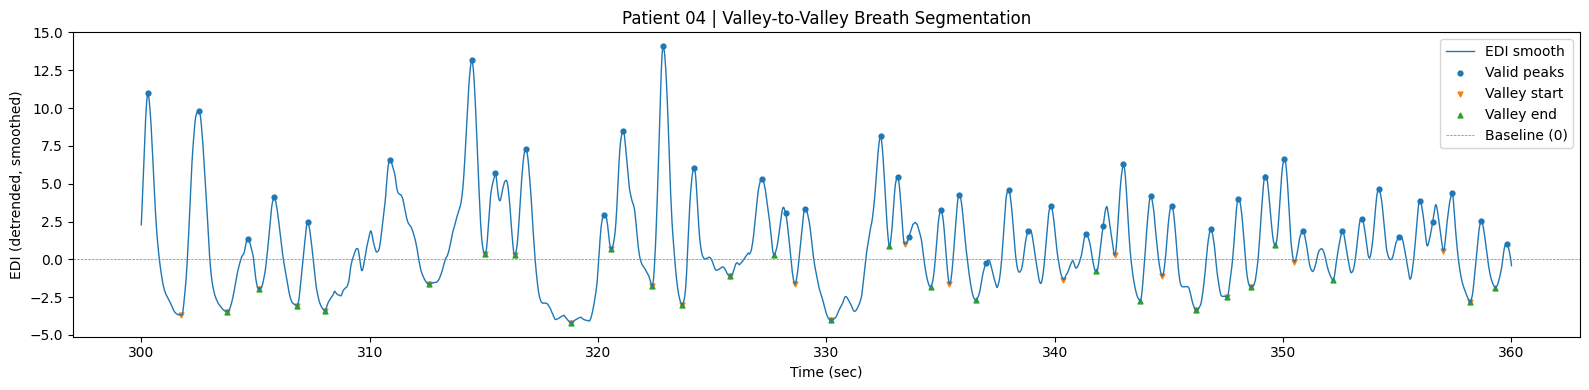

In [16]:
# Visualization
PLOT_START_SEC = 300
PLOT_DURATION_SEC = 60

# Quick plot (windowed)
mask = (time_sec >= PLOT_START_SEC) & (time_sec <= (PLOT_START_SEC + PLOT_DURATION_SEC))
idx = np.flatnonzero(mask)
if len(idx) == 0:
    raise ValueError('No samples in plot range. Adjust PLOT_START_SEC/PLOT_DURATION_SEC.')

i0, i1 = idx[0], idx[-1]
plt.figure(figsize=(16, 4))
plt.plot(time_sec[i0:i1+1], edi_smooth[i0:i1+1], lw=1.0, label='EDI smooth')

apnea_idx = np.flatnonzero(apnea_final_mask[i0:i1+1]) + i0
if len(apnea_idx):
    plt.scatter(time_sec[apnea_idx], edi_smooth[apnea_idx], s=2, alpha=0.25, label='Excluded apnea region')

peak_in = peak_idx[(peak_idx >= i0) & (peak_idx <= i1)]
plt.scatter(time_sec[peak_in], edi_smooth[peak_in], s=12, label='Valid peaks')

if len(breaths_all_df):
    bsub = breaths_all_df[(breaths_all_df['v_start_idx'] >= i0) & (breaths_all_df['v_end_idx'] <= i1)]
    if len(bsub):
        v1 = bsub['v_start_idx'].to_numpy(dtype=int)
        v2 = bsub['v_end_idx'].to_numpy(dtype=int)
        plt.scatter(time_sec[v1], edi_smooth[v1], s=12, marker='v', label='Valley start')
        plt.scatter(time_sec[v2], edi_smooth[v2], s=12, marker='^', label='Valley end')

plt.axhline(0, color='gray', linestyle='--', linewidth=0.5, label='Baseline (0)')
plt.title(f'Patient {PATIENT_ID} | Valley-to-Valley Breath Segmentation')
plt.xlabel('Time (sec)')
plt.ylabel('EDI (detrended, smoothed)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()



# Analyze All Breath Cluster Statistics

In [ ]:
all_cluster_summary_statistics = pd.read_csv("/home/jhkim/NAVA/03_LABEL_BREATH/notebooks/outputs/03_breath_detect/20260301/all_patients_cluster_statistics.csv")
all_cluster_summary_statistics.head(10)

,patient_id,cluster_label,breath_duration_sec_count,breath_duration_sec_mean,breath_duration_sec_std,breath_duration_sec_median,signal_len_count,signal_len_mean,signal_len_std,signal_len_median,signal_len_count.1,signal_len_mean.1,signal_len_std.1,signal_len_median.1,max_edi_count,max_edi_mean,max_edi_std,max_edi_median,min_edi_count,min_edi_mean,min_edi_std,min_edi_median,mean_edi_count,mean_edi_mean,mean_edi_std,mean_edi_median,std_edi_count,std_edi_mean,std_edi_std,std_edi_median,ptp_edi_count,ptp_edi_mean,ptp_edi_std,ptp_edi_median,auc_count,auc_mean,auc_std,auc_median,auc_abs_count,auc_abs_mean,auc_abs_std,auc_abs_median,auc_pos_count,auc_pos_mean,auc_pos_std,auc_pos_median,peak_edi_count,peak_edi_mean,peak_edi_std,peak_edi_median,rise_time_sec_count,rise_time_sec_mean,rise_time_sec_std,rise_time_sec_median,fall_time_sec_count,fall_time_sec_mean,fall_time_sec_std,fall_time_sec_median,rise_slope_count,rise_slope_mean,rise_slope_std,rise_slope_median,fall_slope_count,fall_slope_mean,fall_slope_std,fall_slope_median
0,3,0,48,2.837083,1.027376,2.595,48,284.708333,102.737625,260.5,48,284.708333,102.737625,260.5,48,26.820630,5.539692,25.990437,48,-2.254294,1.549915,-1.916500,48,5.862124,2.652506,5.546982,48,9.223615,2.220478,9.001284,48,29.074924,6.127694,28.182562,48,14.906499,4.661285,14.479416,48,18.780755,4.108262,17.567885,48,16.843627,4.042456,16.368646,48,26.820630,5.539692,25.990437,48,1.217708,0.868413,0.940,48,1.619375,0.641506,1.525,48,30.217255,14.939504,27.146576,48,20.292910,8.590913,18.486229
1,3,1,1,5.550000,NaN,5.550,1,556.000000,NaN,556.0,1,556.000000,NaN,556.0,1,25.554750,NaN,25.554750,1,-2.237375,NaN,-2.237375,1,3.366021,NaN,3.366021,1,7.509473,NaN,7.509473,1,27.792125,NaN,27.792125,1,18.733472,NaN,18.733472,1,27.769916,NaN,27.769916,1,23.251694,NaN,23.251694,1,25.554750,NaN,25.554750,1,1.600000,NaN,1.600,1,3.950000,NaN,3.950,1,16.872656,NaN,16.872656,1,7.035981,NaN,7.035981
2,3,2,2,2.210000,0.169706,2.210,2,222.000000,16.970563,222.0,2,222.000000,16.970563,222.0,2,37.110250,9.088797,37.110250,2,-3.082125,3.256404,-3.082125,2,14.126451,1.797947,14.126451,2,13.432791,2.860675,13.432791,2,40.192375,5.832394,40.192375,2,31.223969,1.577393,31.223969,2,32.707750,0.397276,32.707750,2,31.965859,0.590059,31.965859,2,37.110250,9.088797,37.110250,2,1.045000,0.261630,1.045,2,1.165000,0.091924,1.165,2,38.295488,18.717577,38.295488,2,34.100249,1.853935,34.100249
3,3,3,1,2.730000,NaN,2.730,1,274.000000,NaN,274.0,1,274.000000,NaN,274.0,1,57.892375,NaN,57.892375,1,-3.994000,NaN,-3.994000,1,17.448547,NaN,17.448547,1,20.417118,NaN,20.417118,1,61.886375,NaN,61.886375,1,47.844286,NaN,47.844286,1,52.560454,NaN,52.560454,1,50.202370,NaN,50.202370,1,57.892375,NaN,57.892375,1,1.040000,NaN,1.040,1,1.690000,NaN,1.690,1,59.506130,NaN,59.506130,1,36.066124,NaN,36.066124
4,3,4,1,2.620000,NaN,2.620,1,263.000000,NaN,263.0,1,263.000000,NaN,263.0,1,61.400750,NaN,61.400750,1,-4.581125,NaN,-4.581125,1,21.066800,NaN,21.066800,1,21.286207,NaN,21.286207,1,65.981875,NaN,65.981875,1,55.429292,NaN,55.429292,1,58.028538,NaN,58.028538,1,56.728915,NaN,56.728915,1,61.400750,NaN,61.400750,1,1.710000,NaN,1.710,1,0.910000,NaN,0.910,1,38.585892,NaN,38.585892,1,67.627747,NaN,67.627747
5,3,5,1,3.340000,NaN,3.340,1,335.000000,NaN,335.0,1,335.000000,NaN,335.0,1,49.731750,NaN,49.731750,1,-2.665500,NaN,-2.665500,1,13.357146,NaN,13.357146,1,14.356209,NaN,14.356209,1,52.397250,NaN,52.397250,1,44.771227,NaN,44.771227,1,46.970453,NaN,46.970453,1,45.870840,NaN,45.870840,1,49.731750,NaN,49.731750,1,1.800000,NaN,1.800,1,1.540000,NaN,1.540,1,29.109583,NaN,29.109583,1,33.781737,NaN,33.781737
6,3,6,1364,2.159787,1.008917,1.900,1364,216.978739,100.891748,191.0,1364,216.978739,100.891748,191.0,1364,5.665860,4.515565,4.530250,1364,-1.596164,0.775315,-1.466125,1364,0.954828,1.416706,0.661701,1364,2.300658,1.476378,1.941417,1364,7.262023,4.628181,6.099875,1364,2.090208,3.173740,1.294327,1364,4.320322,3.192536,3.318302,1364,3.205265,3.016552,2.277115,1364,5.652739,4.527869,4.52

In [33]:
all_cluster_statistics.columns

Index(['patient_id', 'cluster_label', 'breath_duration_sec_count',
       'breath_duration_sec_mean', 'breath_duration_sec_std',
       'breath_duration_sec_median', 'signal_len_count', 'signal_len_mean',
       'signal_len_std', 'signal_len_median', 'signal_len_count.1',
       'signal_len_mean.1', 'signal_len_std.1', 'signal_len_median.1',
       'max_edi_count', 'max_edi_mean', 'max_edi_std', 'max_edi_median',
       'min_edi_count', 'min_edi_mean', 'min_edi_std', 'min_edi_median',
       'mean_edi_count', 'mean_edi_mean', 'mean_edi_std', 'mean_edi_median',
       'std_edi_count', 'std_edi_mean', 'std_edi_std', 'std_edi_median',
       'ptp_edi_count', 'ptp_edi_mean', 'ptp_edi_std', 'ptp_edi_median',
       'auc_count', 'auc_mean', 'auc_std', 'auc_median', 'auc_abs_count',
       'auc_abs_mean', 'auc_abs_std', 'auc_abs_median', 'auc_pos_count',
       'auc_pos_mean', 'auc_pos_std', 'auc_pos_median', 'peak_edi_count',
       'peak_edi_mean', 'peak_edi_std', 'peak_edi_median',
       

## Major vs Non Major Reclassification (All Patients)

- Source files: `all_patients_cluster_statistics.csv`, `all_patients_cluster_breath_stats.csv`
- Rule:
  - Major cluster per patient = cluster with maximum `signal_len_count`
  - Non Major = all other clusters merged
- Outputs:
  - patient-wise grouped bar plots (Major vs Non Major) with sample count annotations
  - summary table used for plotting



In [ ]:
# Major vs Non Major analysis using all_patients_cluster*.csv
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ANALYSIS_OUT_DIR = Path('/home/jhkim/NAVA/03_LABEL_BREATH/notebooks/outputs/03_breath_detect') / ANALYSIS_FOLDER
stats_csv = ANALYSIS_OUT_DIR / 'all_patients_cluster_statistics.csv'
breath_csv = ANALYSIS_OUT_DIR / 'all_patients_cluster_breath_stats.csv'
plot_out_dir = ANALYSIS_OUT_DIR / 'major_vs_non_major'
plot_out_dir.mkdir(parents=True, exist_ok=True)

cluster_stats = pd.read_csv(stats_csv)
breath_stats = pd.read_csv(breath_csv)

# Resolve duplicated count columns robustly
if 'signal_len_count' in cluster_stats.columns:
    count_col = 'signal_len_count'
else:
    candidates = [c for c in cluster_stats.columns if c.startswith('signal_len_count')]
    if not candidates:
        raise KeyError('Cannot find signal_len_count column in all_patients_cluster_statistics.csv')
    count_col = candidates[0]

# Major cluster per patient: max signal_len_count
major_map = (
    cluster_stats.sort_values(['patient_id', count_col], ascending=[True, False])
    .groupby('patient_id', as_index=False)
    .first()[['patient_id', 'cluster_label']]
    .rename(columns={'cluster_label': 'major_cluster_label'})
)

# Apply major/non-major labels to breath-level table
breath = breath_stats.merge(major_map, on='patient_id', how='left')
breath['cluster_group'] = np.where(
    breath['cluster_label'] == breath['major_cluster_label'],
    'Major',
    'Non Major'
)

metrics = [
    'breath_duration_sec',
    'max_edi',
    'mean_edi',
    'auc',
    'rise_time_sec',
    'fall_time_sec',
    'rise_slope',
    'fall_slope',
]

# Summary for plotting: mean + std + n
mean_summary = breath.groupby(['patient_id', 'cluster_group'])[metrics].mean().reset_index()
std_summary = breath.groupby(['patient_id', 'cluster_group'])[metrics].std().reset_index()
count_summary = breath.groupby(['patient_id', 'cluster_group']).size().reset_index(name='n_samples')

plot_summary = mean_summary.merge(std_summary, on=['patient_id', 'cluster_group'], suffixes=('', '_std'))
plot_summary = plot_summary.merge(count_summary, on=['patient_id', 'cluster_group'], how='left')

# Ensure stable patient order
patient_order = sorted(plot_summary['patient_id'].dropna().unique().tolist())


def plot_major_non_major_bar(metric: str, ylabel: str):
    df = plot_summary[['patient_id', 'cluster_group', metric, f'{metric}_std', 'n_samples']].copy()

    pivot_val = df.pivot(index='patient_id', columns='cluster_group', values=metric).reindex(patient_order)
    pivot_std = df.pivot(index='patient_id', columns='cluster_group', values=f'{metric}_std').reindex(patient_order)
    pivot_n = df.pivot(index='patient_id', columns='cluster_group', values='n_samples').reindex(patient_order)

    # Keep both columns even if one is missing
    for col in ['Major', 'Non Major']:
        if col not in pivot_val.columns:
            pivot_val[col] = np.nan
            pivot_std[col] = np.nan
            pivot_n[col] = np.nan

    x = np.arange(len(patient_order))
    width = 0.38

    fig, ax = plt.subplots(figsize=(max(14, len(patient_order) * 0.7), 5))
    bars_major = ax.bar(
        x - width / 2,
        pivot_val['Major'].to_numpy(),
        width,
        yerr=pivot_std['Major'].to_numpy(),
        capsize=3,
        label='Major'
    )
    bars_non = ax.bar(
        x + width / 2,
        pivot_val['Non Major'].to_numpy(),
        width,
        yerr=pivot_std['Non Major'].to_numpy(),
        capsize=3,
        label='Non Major'
    )

    ax.set_xticks(x)
    ax.set_xticklabels([str(int(p)) if float(p).is_integer() else str(p) for p in patient_order], rotation=45)
    ax.set_xlabel('Patient ID')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{metric}: Major vs Non Major (All Patients)')
    ax.legend()
    ax.grid(axis='y', alpha=0.25)

    # annotate sample count on each bar
    y_min, y_max = ax.get_ylim()
    pad = (y_max - y_min) * 0.015
    for i, b in enumerate(bars_major):
        h = b.get_height()
        e = pivot_std['Major'].iloc[i] if pd.notna(pivot_std['Major'].iloc[i]) else 0.0
        n = pivot_n['Major'].iloc[i]
        if np.isfinite(h) and pd.notna(n):
            ax.text(b.get_x() + b.get_width()/2, h + e + pad, f'n={int(n)}', ha='center', va='bottom', fontsize=8)
    for i, b in enumerate(bars_non):
        h = b.get_height()
        e = pivot_std['Non Major'].iloc[i] if pd.notna(pivot_std['Non Major'].iloc[i]) else 0.0
        n = pivot_n['Non Major'].iloc[i]
        if np.isfinite(h) and pd.notna(n):
            ax.text(b.get_x() + b.get_width()/2, h + e + pad, f'n={int(n)}', ha='center', va='bottom', fontsize=8)

    fig.tight_layout()
    out_png = plot_out_dir / f'major_vs_non_major_{metric}.png'
    fig.savefig(out_png, dpi=160)
    plt.show()
    plt.close(fig)


plot_major_non_major_bar('breath_duration_sec', 'Breath Duration (sec)')
plot_major_non_major_bar('max_edi', 'Max EDI')
plot_major_non_major_bar('mean_edi', 'Mean EDI')
plot_major_non_major_bar('auc', 'AUC')
plot_major_non_major_bar('rise_time_sec', 'Rise Time (sec)')
plot_major_non_major_bar('fall_time_sec', 'Fall Time (sec)')
plot_major_non_major_bar('rise_slope', 'Rise Slope')
plot_major_non_major_bar('fall_slope', 'Fall Slope')

# Save merged table
major_non_major_table = breath[['patient_id','breath_id','cluster_label','major_cluster_label','cluster_group'] + metrics].copy()
major_non_major_table.to_csv(plot_out_dir / 'major_non_major_breath_level.csv', index=False)
plot_summary.to_csv(plot_out_dir / 'major_non_major_patient_summary.csv', index=False)

print(f'Saved plots and tables to: {plot_out_dir}')
plot_summary.head()

